# Final Evaluation — AI4I 2020 Predictive Maintenance

## Objective

Evaluate the final candidate systems on an untouched holdout:

1. Documented HDF/PWF/OSF rules
2. Leakage-safe ML
3. Hybrid rules + ML

The final holdout is not used for feature selection, model selection or threshold tuning.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, brier_score_loss
)
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

DATA_PATH = Path("../data/raw/ai4i2020.csv")
df = pd.read_csv(DATA_PATH)

TARGET = "Machine failure"
RANDOM_STATE = 42

raw_features = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

engineered_features = raw_features + [
    "temp_diff",
    "power_w",
    "wear_torque",
    "strain_ratio"
]

# Feature engineering
df["temp_diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]
df["power_w"] = (
    df["Torque [Nm]"] * df["Rotational speed [rpm]"] * 2 * np.pi / 60
)
strain_limits = {"L": 11000, "M": 12000, "H": 13000}
df["wear_torque"] = df["Tool wear [min]"] * df["Torque [Nm]"]
df["strain_limit"] = df["Type"].map(strain_limits)
df["strain_ratio"] = df["wear_torque"] / df["strain_limit"]

# Documented rules
df["rule_HDF"] = (
    (df["temp_diff"] < 8.6)
    & (df["Rotational speed [rpm]"] < 1380)
)
df["rule_PWF"] = (
    (df["power_w"] < 3500)
    | (df["power_w"] > 9000)
)
df["rule_OSF"] = df["wear_torque"] > df["strain_limit"]
df["rule_any"] = df["rule_HDF"] | df["rule_PWF"] | df["rule_OSF"]

# Untouched final holdout: last 20% in original order.
split_point = int(len(df) * 0.8)
dev = df.iloc[:split_point].copy()
holdout = df.iloc[split_point:].copy()

print("Development rows:", len(dev))
print("Holdout rows:", len(holdout))
print("Holdout failures:", int(holdout[TARGET].sum()))

Development rows: 8000
Holdout rows: 2000
Holdout failures: 39


## 1. Define preprocessing and candidate models

In [2]:
def make_preprocessor(feature_columns):
    numeric = [c for c in feature_columns if c != "Type"]

    return ColumnTransformer(
        [
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["Type"]),
            ("num", "passthrough", numeric)
        ]
    )

def make_pipeline(model, feature_columns):
    return Pipeline([
        ("prep", make_preprocessor(feature_columns)),
        ("model", model)
    ])

ml_feature_set = engineered_features

candidate_models = {
    "LogReg": make_pipeline(
        LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),
        ml_feature_set
    ),
    "RandomForest": make_pipeline(
        RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced_subsample",
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        ml_feature_set
    ),
    "HistGB": make_pipeline(
        HistGradientBoostingClassifier(
            max_iter=300,
            learning_rate=0.05,
            random_state=RANDOM_STATE
        ),
        ml_feature_set
    )
}

try:
    from xgboost import XGBClassifier
    candidate_models["XGBoost"] = make_pipeline(
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            scale_pos_weight=1.0
        ),
        ml_feature_set
    )
except ImportError:
    pass

## 2. Select the final ML model using development data only

Use stratified out-of-fold Average Precision as the selection metric.

The holdout remains untouched.

In [3]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

y_dev = dev[TARGET].astype(int).reset_index(drop=True)
X_dev = dev[ml_feature_set].reset_index(drop=True)

selection_rows = []

for name, model in candidate_models.items():
    fold_scores = []

    for train_idx, test_idx in cv.split(X_dev, y_dev):
        m = clone(model)
        m.fit(X_dev.iloc[train_idx], y_dev.iloc[train_idx])

        score = m.predict_proba(X_dev.iloc[test_idx])[:, 1]

        fold_scores.append(
            average_precision_score(
                y_dev.iloc[test_idx],
                score
            )
        )

    selection_rows.append({
        "model": name,
        "cv_average_precision_mean": np.mean(fold_scores),
        "cv_average_precision_std": np.std(fold_scores, ddof=1)
    })

selection_df = (
    pd.DataFrame(selection_rows)
    .sort_values("cv_average_precision_mean", ascending=False)
)

selection_df

,model,cv_average_precision_mean,cv_average_precision_std
1,RandomForest,0.906620,0.034961
3,XGBoost,0.903334,0.050266
2,HistGB,0.902181,0.044783
0,LogReg,0.451438,0.045212


## 3. Choose a model and obtain development OOF probabilities

Threshold selection must happen on development data only.

In [4]:
best_model_name = selection_df.iloc[0]["model"]
best_model = candidate_models[best_model_name]

print("Selected ML model:", best_model_name)

oof_dev = np.zeros(len(dev))

for train_idx, test_idx in cv.split(X_dev, y_dev):
    m = clone(best_model)
    m.fit(X_dev.iloc[train_idx], y_dev.iloc[train_idx])
    oof_dev[test_idx] = m.predict_proba(X_dev.iloc[test_idx])[:, 1]

Selected ML model: RandomForest


## 4. Optimize the ML decision threshold on development OOF predictions

There is no supplied business cost matrix, so use maximum F1 as a transparent
default objective.

The threshold is selected **only from development OOF predictions**.

Selected threshold: 0.5149999999999999
threshold    0.515000
precision    0.954545
recall       0.840000
f1           0.893617
Name: 93, dtype: float64


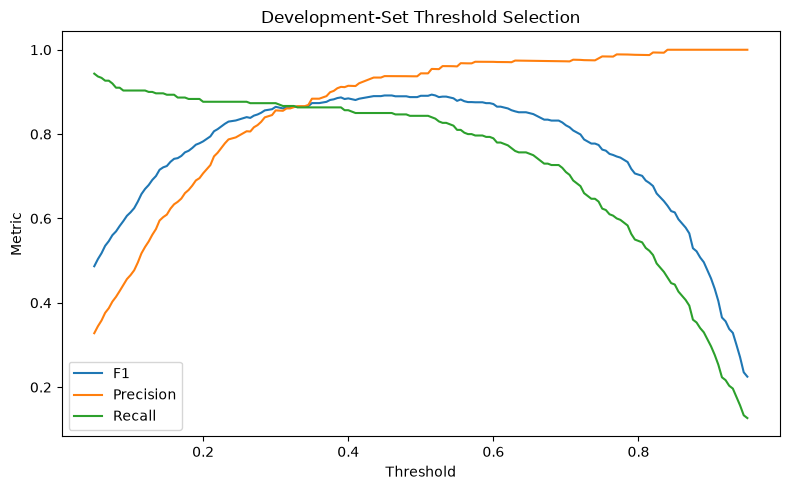

In [5]:
threshold_grid = np.linspace(0.05, 0.95, 181)

threshold_rows = []

for threshold in threshold_grid:
    pred = (oof_dev >= threshold).astype(int)

    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_dev, pred, zero_division=0),
        "recall": recall_score(y_dev, pred, zero_division=0),
        "f1": f1_score(y_dev, pred, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_rows)

best_threshold_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

selected_threshold = float(best_threshold_row["threshold"])

print("Selected threshold:", selected_threshold)
print(best_threshold_row)

plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Metric")
plt.title("Development-Set Threshold Selection")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Select a hybrid threshold on development data

The hybrid system triggers if either:
- a documented rule fires, or
- the ML risk exceeds its selected threshold.

For simplicity, use the same threshold chosen above.

In [6]:
rule_dev = (
    dev["rule_HDF"]
    | dev["rule_PWF"]
    | dev["rule_OSF"]
).to_numpy()

hybrid_dev_pred = rule_dev | (oof_dev >= selected_threshold)

hybrid_dev_metrics = {
    "precision": precision_score(y_dev, hybrid_dev_pred, zero_division=0),
    "recall": recall_score(y_dev, hybrid_dev_pred, zero_division=0),
    "f1": f1_score(y_dev, hybrid_dev_pred, zero_division=0),
}

hybrid_dev_metrics

{'precision': 0.955719557195572,
 'recall': 0.8633333333333333,
 'f1': 0.9071803852889667}

## 6. Fit the selected ML model on all development data

This is the final fit before the holdout is evaluated.

In [7]:
X_holdout = holdout[ml_feature_set].copy()
y_holdout = holdout[TARGET].astype(int).to_numpy()

final_ml_model = clone(best_model)
final_ml_model.fit(
    dev[ml_feature_set],
    dev[TARGET].astype(int)
)

holdout_ml_score = final_ml_model.predict_proba(X_holdout)[:, 1]
holdout_ml_pred = (holdout_ml_score >= selected_threshold).astype(int)

holdout_rule_pred = holdout["rule_any"].astype(int).to_numpy()

holdout_hybrid_pred = (
    holdout_rule_pred
    | (holdout_ml_score >= selected_threshold)
)

## 7. Final untouched holdout metrics

In [8]:
def classification_report_dict(y_true, pred, score=None):
    tn, fp, fn, tp = confusion_matrix(
        y_true, pred, labels=[0, 1]
    ).ravel()

    result = {
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }

    if score is not None and len(np.unique(y_true)) == 2:
        result["roc_auc"] = roc_auc_score(y_true, score)
        result["average_precision"] = average_precision_score(y_true, score)
        result["brier_score"] = brier_score_loss(y_true, score)

    return result

rule_report = classification_report_dict(
    y_holdout,
    holdout_rule_pred,
    holdout_rule_pred.astype(float)
)

ml_report = classification_report_dict(
    y_holdout,
    holdout_ml_pred,
    holdout_ml_score
)

hybrid_score = np.maximum(
    holdout_rule_pred.astype(float),
    holdout_ml_score
)

hybrid_report = classification_report_dict(
    y_holdout,
    holdout_hybrid_pred,
    hybrid_score
)

final_reports = pd.DataFrame([
    {"system": "Documented rules", **rule_report},
    {"system": "Leakage-safe ML", **ml_report},
    {"system": "Hybrid rules + ML", **hybrid_report},
])

final_reports

,system,precision,recall,f1,TN,FP,FN,TP,roc_auc,average_precision,brier_score
0,Documented rules,1.0,0.717949,0.835821,1961,0,11,28,0.858974,0.723449,0.005500
1,Leakage-safe ML,1.0,0.717949,0.835821,1961,0,11,28,0.972025,0.785072,0.006530
2,Hybrid rules + ML,1.0,0.717949,0.835821,1961,0,11,28,0.972025,0.785072,0.006125


## 8. Confusion matrices

In [9]:
for system_name, pred in [
    ("Documented rules", holdout_rule_pred),
    ("Leakage-safe ML", holdout_ml_pred),
    ("Hybrid rules + ML", holdout_hybrid_pred),
]:
    cm = confusion_matrix(y_holdout, pred, labels=[0, 1])

    print(system_name)
    print(pd.DataFrame(
        cm,
        index=["Actual 0", "Actual 1"],
        columns=["Predicted 0", "Predicted 1"]
    ))
    print()

Documented rules
          Predicted 0  Predicted 1
Actual 0         1961            0
Actual 1           11           28

Leakage-safe ML
          Predicted 0  Predicted 1
Actual 0         1961            0
Actual 1           11           28

Hybrid rules + ML
          Predicted 0  Predicted 1
Actual 0         1961            0
Actual 1           11           28



## 9. Final interpretation

Compare the three systems using the holdout results.

Questions:
1. Does ML outperform the documented rules?
2. Does the hybrid system add useful recall without creating unacceptable false positives?
3. Does the final conclusion agree with the development/validation experiments?
4. Is the model's advantage large enough to justify its complexity?

In [10]:
print("Selected ML model:", best_model_name)
print("Selected threshold:", selected_threshold)

print("\nFinal holdout comparison:")
display(
    final_reports[
        [
            "system",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "average_precision",
            "TN",
            "FP",
            "FN",
            "TP"
        ]
    ]
)

print("\nHoldout size:", len(holdout))
print("Holdout failures:", int(y_holdout.sum()))

Selected ML model: RandomForest
Selected threshold: 0.5149999999999999

Final holdout comparison:


,system,precision,recall,f1,roc_auc,average_precision,TN,FP,FN,TP
0,Documented rules,1.0,0.717949,0.835821,0.858974,0.723449,1961,0,11,28
1,Leakage-safe ML,1.0,0.717949,0.835821,0.972025,0.785072,1961,0,11,28
2,Hybrid rules + ML,1.0,0.717949,0.835821,0.972025,0.785072,1961,0,11,28



Holdout size: 2000
Holdout failures: 39


## Limitations

- The dataset is synthetic rather than plant-specific industrial telemetry.
- There is no real timestamp column, so ordered/block testing is a robustness stress test,
  not evidence of true future forecasting.
- The documented HDF/PWF/OSF mechanisms are benchmark-generation rules and should not
  automatically be assumed to represent every real-world machine.
- Threshold selection here optimizes F1 because no operational false-positive/false-negative
  cost matrix was supplied.
- The final holdout is used once for final evaluation and must not be tuned against.

## Final conclusion

The final project conclusion must be based on the computed holdout results.

Do not claim:
- universal superiority of physics rules;
- universal superiority of ML;
- true temporal forecasting;
- provably unpredictable residual failures.

The correct conclusion is the simplest system whose performance and limitations are
supported by the complete analysis.